# EDA — Part 2: Exposure Density & Sparsity

Examines exposure density and sparsity patterns across H3 cells


In [1]:
# External prerequisite: county-boundary maps download Census TIGER data at runtime.
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from shapely.geometry import Polygon
import geopandas as gpd
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

from scipy import stats

In [2]:
DATA_PATH = Path('../../dataset/Capstone2025_nsi_lvl9_with_landcover_and_color.csv.gz')
FIGURES_DIR = Path('../../figures/eda')
TABLES_DIR = Path('../../results/tables')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, compression='gzip', low_memory=False)
print(f"Dataset shape: {df.shape}")

Dataset shape: (2417766, 8)


## Total exposure per H3 cell


In [3]:
exposure_per_h3 = df.groupby('h3')['clr_cc'].sum().reset_index(name='total_exposure')
exposure_per_h3 = exposure_per_h3.sort_values('total_exposure', ascending=False)

print("Exposure per H3 cell summary:")
print(exposure_per_h3['total_exposure'].describe())
print(f"\nMin: {exposure_per_h3['total_exposure'].min()}")
print(f"Max: {exposure_per_h3['total_exposure'].max()}")
print(f"Median: {exposure_per_h3['total_exposure'].median():.1f}")
print(f"Mean: {exposure_per_h3['total_exposure'].mean():.1f}")

display(exposure_per_h3.head(10))


Exposure per H3 cell summary:
count    221108.000000
mean         43.997680
std          52.944971
min           2.000000
25%           4.000000
50%          21.000000
75%          73.000000
max        2195.000000
Name: total_exposure, dtype: float64

Min: 2
Max: 2195
Median: 21.0
Mean: 44.0


,h3,total_exposure
23518,89283082a0bffff,2195
163724,8929a41136bffff,1278
165589,8929a41ad17ffff,1236
153344,8929a1d666bffff,1077
145137,8929a199d47ffff,1035
23548,89283082ac7ffff,991
145124,8929a199d03ffff,966
165610,8929a41ad93ffff,948
23592,89283082bc3ffff,945
145099,8929a199c63ffff,942


## Global exposure distribution


In [4]:
median_exposure = exposure_per_h3['total_exposure'].median()
pct_below_5 = (exposure_per_h3['total_exposure'] < 5).mean() * 100
pct_below_10 = (exposure_per_h3['total_exposure'] < 10).mean() * 100
pct_below_20 = (exposure_per_h3['total_exposure'] < 20).mean() * 100

print(f"Median exposure: {median_exposure:.1f}")
print(f"% of H3 cells with <5 structures: {pct_below_5:.1f}%")
print(f"% of H3 cells with <10 structures: {pct_below_10:.1f}%")
print(f"% of H3 cells with <20 structures: {pct_below_20:.1f}%")


Median exposure: 21.0
% of H3 cells with <5 structures: 26.2%
% of H3 cells with <10 structures: 38.3%
% of H3 cells with <20 structures: 48.9%


## Distribution plots


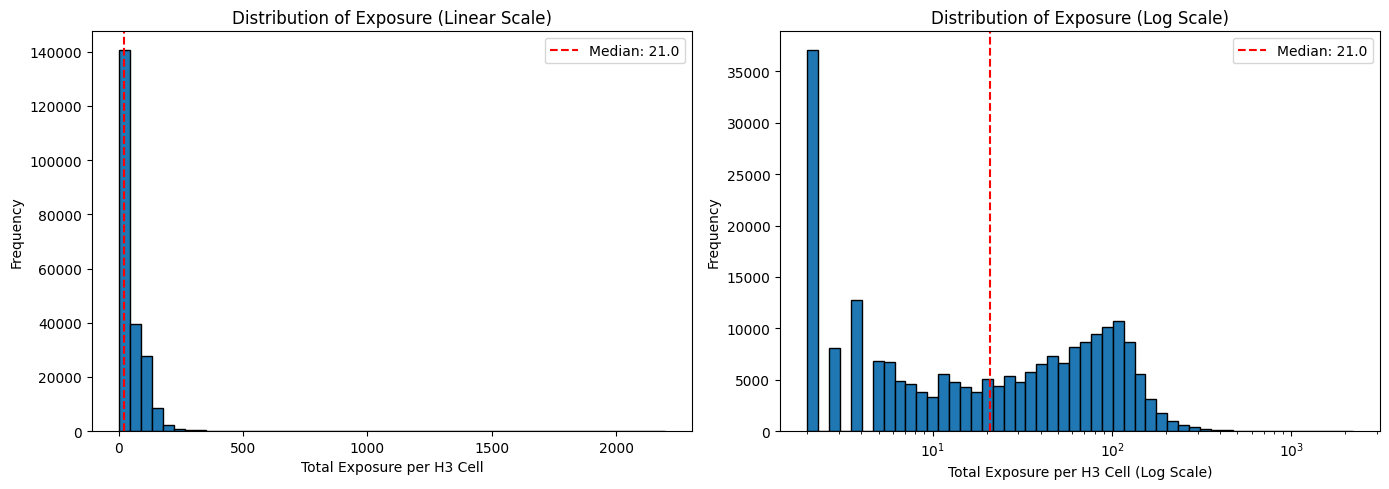

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scale representative of actual exposure (structures per H3 cell)
exp_vals = exposure_per_h3['total_exposure'].values
x_max_hist = max(80, int(np.ceil(np.percentile(exp_vals, 99.5) * 1.05 / 10) * 10))
axes[0].hist(exposure_per_h3['total_exposure'], bins=50, edgecolor='black')
axes[0].set_xlim(0, x_max_hist)
axes[0].set_xlabel('Total Exposure per H3 Cell')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Exposure (Linear Scale)')
axes[0].axvline(median_exposure, color='red', linestyle='--', label=f'Median: {median_exposure:.1f}')
axes[0].legend()

# Create log-spaced bins for proper log-scale histogram
min_exposure = exposure_per_h3['total_exposure'].min()
max_exposure = exposure_per_h3['total_exposure'].max()
log_bins = np.logspace(np.log10(min_exposure), np.log10(max_exposure), num=51)

axes[1].hist(exposure_per_h3['total_exposure'], bins=log_bins, edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('Total Exposure per H3 Cell (Log Scale)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Exposure (Log Scale)')
axes[1].axvline(median_exposure, color='red', linestyle='--', label=f'Median: {median_exposure:.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


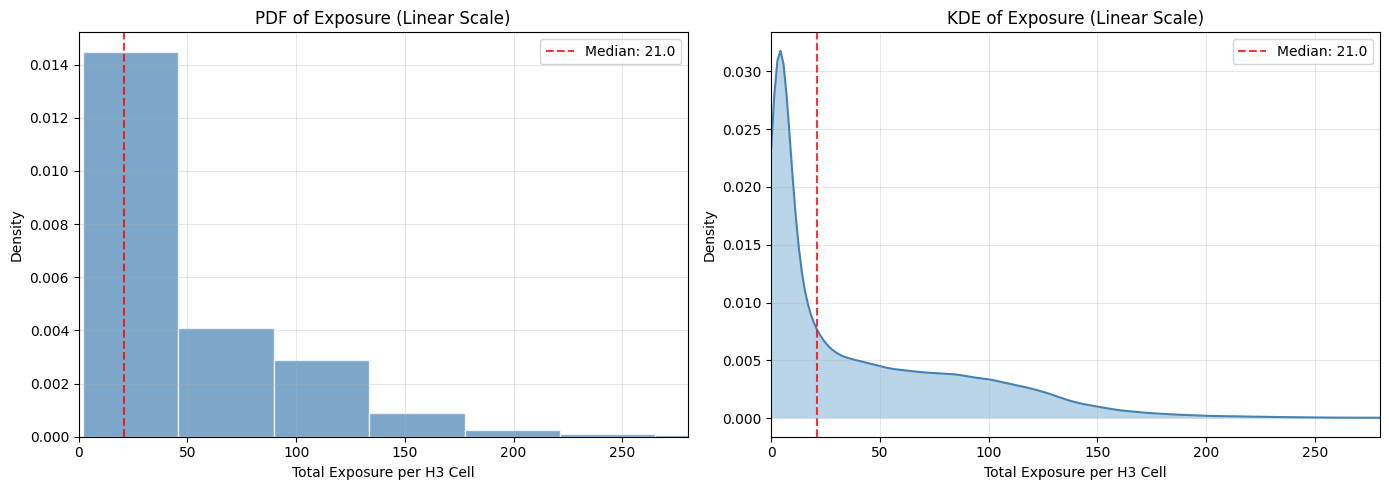

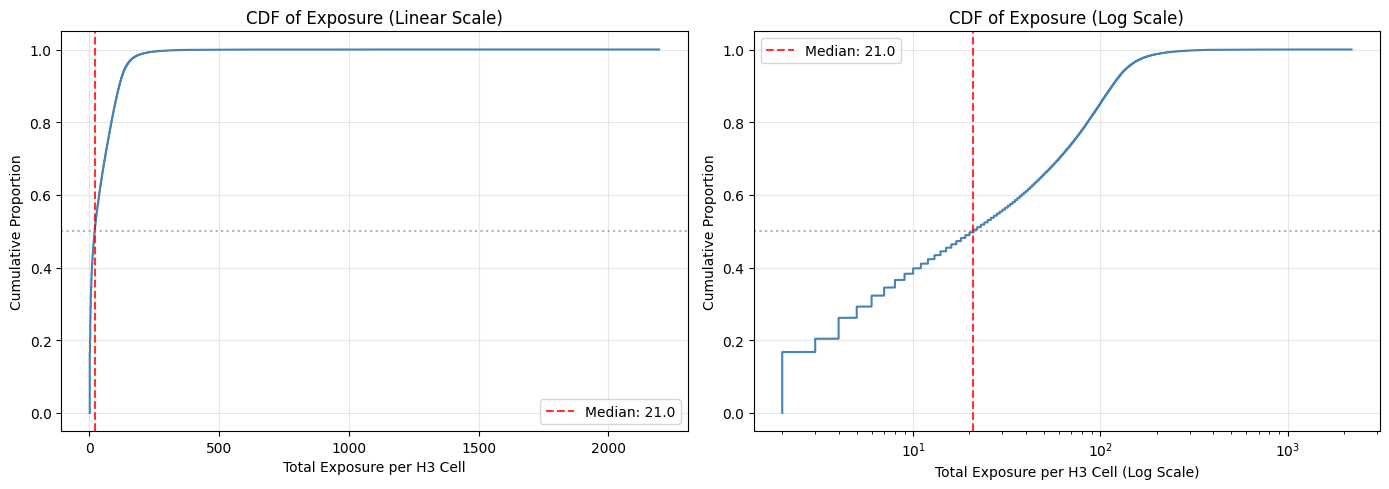

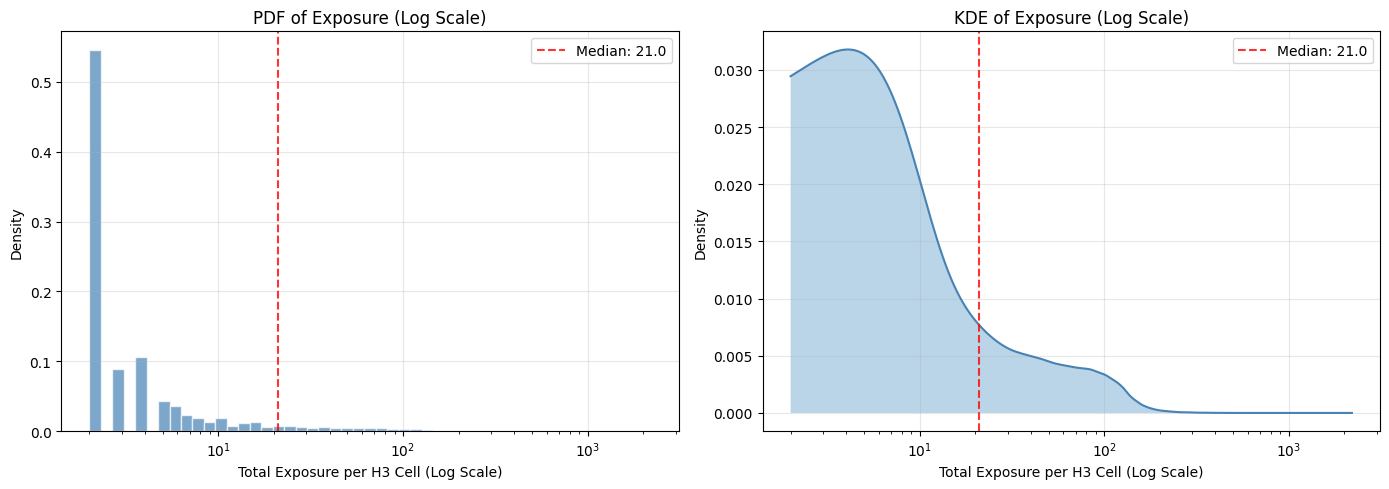

In [23]:
# PDF, CDF and KDE (Kernel Density Estimate) for exposure distribution

x = exposure_per_h3['total_exposure'].sort_values().values
n = len(x)

# PDF and KDE (linear scale) — scale representative of actual exposure (structures per H3 cell)
x_max_data = np.percentile(x, 99.5)  # focus on bulk, avoid extreme tail stretching axis
x_max_zoom = max(80, int(np.ceil(x_max_data * 1.05 / 10) * 10))  # 5% buffer, round to 10s
kde = stats.gaussian_kde(x, bw_method='scott')
x_grid = np.linspace(0, x_max_zoom, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# PDF (normalized histogram)
axes[0].hist(x, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xlim(0, x_max_zoom)
axes[0].set_xlabel('Total Exposure per H3 Cell')
axes[0].set_ylabel('Density')
axes[0].set_title('PDF of Exposure (Linear Scale)')
axes[0].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KDE
axes[1].plot(x_grid, kde(x_grid), color='steelblue')
axes[1].fill_between(x_grid, kde(x_grid), alpha=0.3)
axes[1].set_xlim(0, x_max_zoom)
axes[1].set_xlabel('Total Exposure per H3 Cell')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of Exposure (Linear Scale)')
axes[1].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_pdf_kde.png', dpi=150, bbox_inches='tight')
plt.show()

# CDF (Cumulative Distribution Function)
cdf = np.arange(1, n + 1) / n
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = exposure_per_h3['total_exposure'].sort_values().values
n = len(x)
cdf = np.arange(1, n + 1) / n

# CDF - linear scale
axes[0].plot(x, cdf, color='steelblue')
axes[0].set_xlabel('Total Exposure per H3 Cell')
axes[0].set_ylabel('Cumulative Proportion')
axes[0].set_title('CDF of Exposure (Linear Scale)')
axes[0].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.6)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDF - log scale on x-axis
axes[1].plot(x, cdf, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_xlabel('Total Exposure per H3 Cell (Log Scale)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF of Exposure (Log Scale)')
axes[1].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.6)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

# PDF and KDE (log scale) for full range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins_log = np.logspace(np.log10(max(0.5, x.min())), np.log10(x.max() + 1), 50)
axes[0].hist(x, bins=bins_log, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Total Exposure per H3 Cell (Log Scale)')
axes[0].set_ylabel('Density')
axes[0].set_title('PDF of Exposure (Log Scale)')
axes[0].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x_grid_log = np.logspace(np.log10(max(0.1, x.min())), np.log10(x.max() + 1), 200)
axes[1].plot(x_grid_log, kde(x_grid_log), color='steelblue')
axes[1].fill_between(x_grid_log, kde(x_grid_log), alpha=0.3)
axes[1].set_xscale('log')
axes[1].set_xlabel('Total Exposure per H3 Cell (Log Scale)')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE of Exposure (Log Scale)')
axes[1].axvline(median_exposure, color='red', linestyle='--', alpha=0.8, label=f'Median: {median_exposure:.1f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_pdf_kde_log.png', dpi=150, bbox_inches='tight')
plt.show()

### Exposure by Landcover Class


In [7]:
h3_landcover_exposure = df.groupby(['h3', 'lc_type'])['clr_cc'].sum().reset_index(name='exposure')
landcover_stats = h3_landcover_exposure.groupby('lc_type')['exposure'].agg([
    'median', 'mean', 'std', 'min', 'max'
]).reset_index()
landcover_stats.columns = ['landcover', 'median_exposure', 'mean_exposure', 'std_exposure', 'min_exposure', 'max_exposure']

landcover_stats['iqr'] = h3_landcover_exposure.groupby('lc_type')['exposure'].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).values

landcover_stats['pct_low_exposure'] = h3_landcover_exposure.groupby('lc_type')['exposure'].apply(
    lambda x: (x < 10).mean() * 100
).values

landcover_stats = landcover_stats.sort_values('median_exposure', ascending=False)

print("Exposure statistics by landcover class:")
display(landcover_stats)


Exposure statistics by landcover class:


,landcover,median_exposure,mean_exposure,std_exposure,min_exposure,max_exposure,iqr,pct_low_exposure
6,urban,79.0,83.789664,63.705611,2,2195,80.0,10.108293
10,urban+grass,49.0,55.944128,43.554098,2,413,68.0,16.117432
8,urban+crop,38.0,46.770062,41.269907,2,263,71.0,28.349272
9,urban+forest,33.0,43.594403,40.008568,2,633,54.0,22.258490
7,urban+barren,29.0,40.445413,38.429377,2,400,51.0,24.692769
12,urban+shrub,16.0,29.182003,34.719367,2,449,35.0,37.081851
11,urban+other,11.0,26.411765,32.471254,4,125,32.0,41.176471
2,forest,4.0,10.288700,15.097625,2,233,9.0,71.350218
3,grass,4.0,8.751509,11.879713,2,134,8.0,74.931432
4,other,4.0,4.000000,NaN,4,4,0.0,100.000000


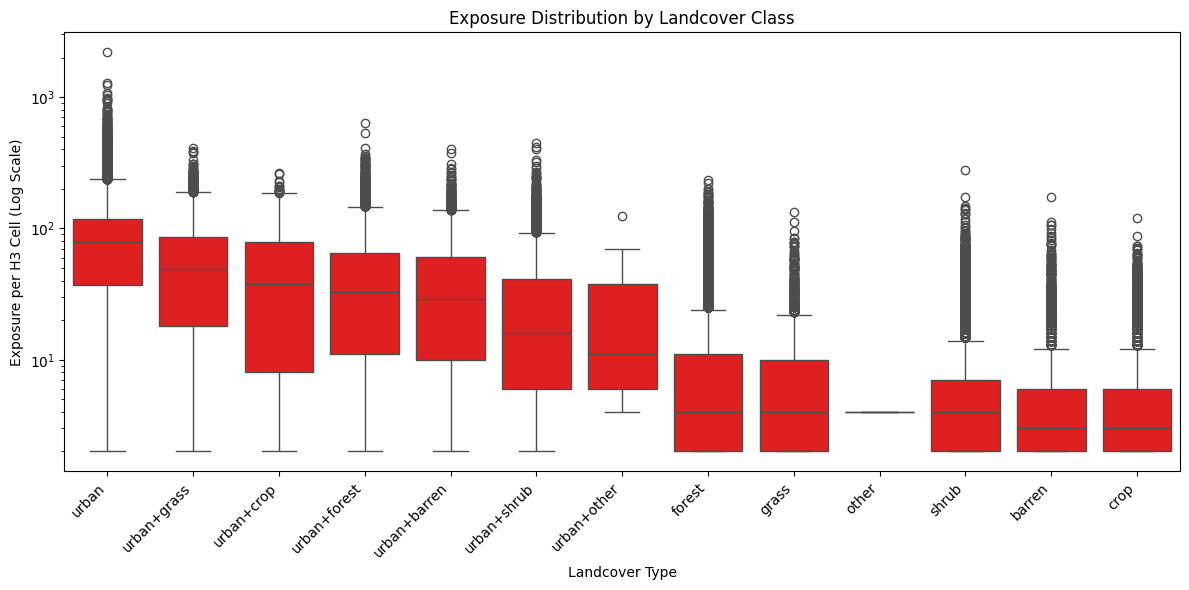

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
landcover_order = landcover_stats.sort_values('median_exposure', ascending=False)['landcover'].values
sns.boxplot(data=h3_landcover_exposure, x='lc_type', y='exposure', order=landcover_order, ax=ax, color='red')
ax.set_yscale('log')
ax.set_xlabel('Landcover Type')
ax.set_ylabel('Exposure per H3 Cell (Log Scale)')
ax.set_title('Exposure Distribution by Landcover Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_by_landcover.png', dpi=150, bbox_inches='tight')
plt.show()


### Exposure by County


In [9]:
county_stats = df.groupby('fips').agg({
    'h3': 'nunique',
    'clr_cc': 'sum'
}).reset_index()
county_stats.columns = ['county_fips', 'n_h3_cells', 'total_exposure']

h3_county_exposure = df.groupby(['h3', 'fips'])['clr_cc'].sum().reset_index(name='exposure')
county_medians = h3_county_exposure.groupby('fips')['exposure'].median().reset_index()
county_medians.columns = ['county_fips', 'median_exposure']

county_stats = county_stats.merge(county_medians, on='county_fips')
county_stats = county_stats.sort_values('median_exposure', ascending=False)

print("Exposure statistics by county:")
display(county_stats.head(20))


Exposure statistics by county:


,county_fips,n_h3_cells,total_exposure,median_exposure
37,6075,948,195059,212.0
29,6059,10161,784918,72.0
18,6037,28581,2207104,69.0
0,6001,5443,393303,65.0
42,6085,7045,466167,60.0
33,6067,7780,418177,47.0
40,6081,2970,171025,45.0
6,6013,5949,290717,39.0
47,6095,2489,124164,39.0
55,6111,4363,219502,36.0


In [10]:
h3_exposure_map = exposure_per_h3.copy()
h3_exposure_map['log_exposure'] = np.log1p(h3_exposure_map['total_exposure'])

print("Spatial density summary:")
print(f"Exposure ranges from {h3_exposure_map['total_exposure'].min()} to {h3_exposure_map['total_exposure'].max()}")
print(f"Log exposure ranges from {h3_exposure_map['log_exposure'].min():.2f} to {h3_exposure_map['log_exposure'].max():.2f}")
print("\nNote: For full spatial visualization, H3 cells can be mapped using their coordinates.")
print("The exposure distribution shows clear urban-rural contrast patterns.")


Spatial density summary:
Exposure ranges from 2 to 2195
Log exposure ranges from 1.10 to 7.69

Note: For full spatial visualization, H3 cells can be mapped using their coordinates.
The exposure distribution shows clear urban-rural contrast patterns.


### Exposure vs Category Diversity


In [11]:
h3_diversity = df.groupby('h3').agg({
    'clr': 'nunique',
    'st_damcat': 'nunique',
    'bldgtype': 'nunique'
}).reset_index()
h3_diversity.columns = ['h3', 'n_colors', 'n_occupancy', 'n_bldgtype']

h3_diversity = h3_diversity.merge(exposure_per_h3, on='h3')

print("Exposure vs category diversity:")
print(f"Correlation (exposure vs n_colors): {h3_diversity['total_exposure'].corr(h3_diversity['n_colors']):.3f}")
print(f"Correlation (exposure vs n_occupancy): {h3_diversity['total_exposure'].corr(h3_diversity['n_occupancy']):.3f}")
print(f"Correlation (exposure vs n_bldgtype): {h3_diversity['total_exposure'].corr(h3_diversity['n_bldgtype']):.3f}")


Exposure vs category diversity:
Correlation (exposure vs n_colors): 0.662
Correlation (exposure vs n_occupancy): 0.259
Correlation (exposure vs n_bldgtype): 0.492


## County maps


### County-level exposure map


C:\Users\sardo\AppData\Local\Temp\ipykernel_37448\1047654499.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Reds")


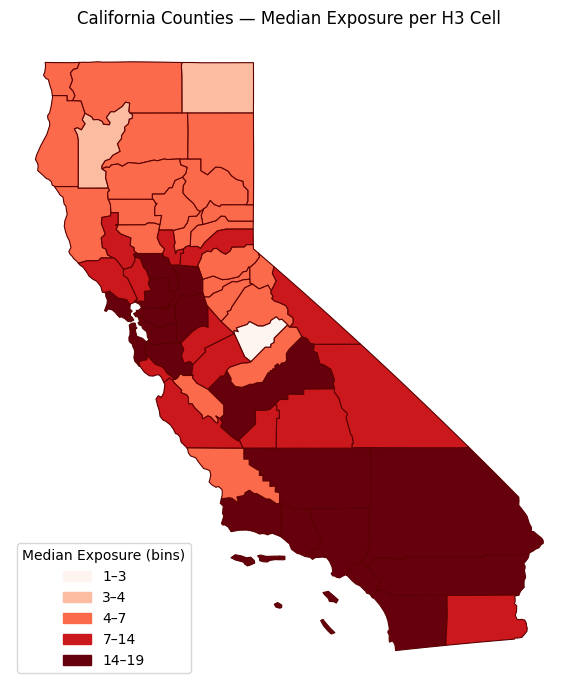

In [12]:
df_county = county_stats.copy()
df_county['county_fips'] = df_county['county_fips'].astype(int).astype(str).str.zfill(5)

counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip")
counties_ca = counties[counties["STATEFP"] == "06"].copy()
counties_ca["county_fips"] = counties_ca["GEOID"]

gdf_county = counties_ca.merge(df_county, on="county_fips", how="left")

breaks = [1.0, 3.0, 4.0, 7.0, 14.0, 19.0]
labels = ["1–3", "3–4", "4–7", "7–14", "14–19"]

fig, ax = plt.subplots(figsize=(7, 7))
cmap = get_cmap("Reds")
norm = BoundaryNorm(breaks, ncolors=cmap.N, clip=True)

gdf_county.plot(
    column="median_exposure",
    cmap=cmap,
    norm=norm,
    linewidth=0.8,
    edgecolor="#5a0000",
    ax=ax,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)

ax.set_axis_off()
ax.set_title("California Counties — Median Exposure per H3 Cell", fontsize=12)

patches = []
for i, lab in enumerate(labels):
    lo, hi = breaks[i], breaks[i+1]
    sample = (lo + hi) / 2
    patches.append(mpatches.Patch(color=cmap(norm(sample)), label=lab))

ax.legend(
    handles=patches,
    title="Median Exposure (bins)",
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_exposure_by_county_map.png', dpi=150, bbox_inches='tight')
plt.show()


### Total exposure by county


C:\Users\sardo\AppData\Local\Temp\ipykernel_37448\1777205374.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_total = get_cmap("Oranges")


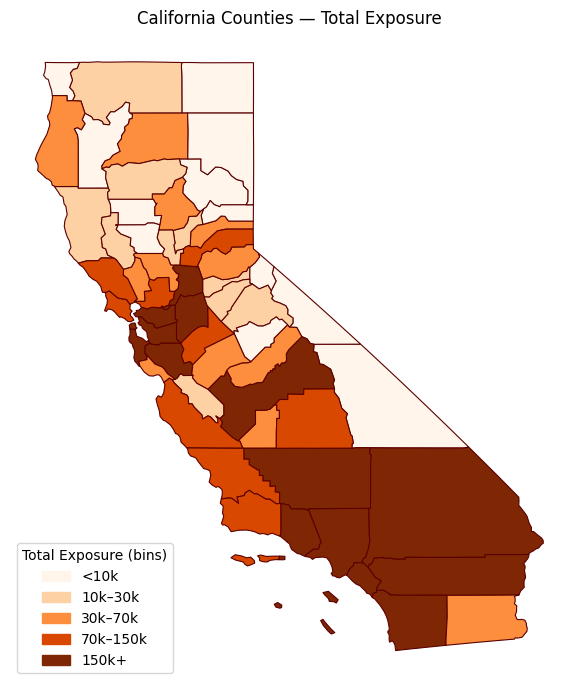

In [13]:
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip")
counties_ca = counties[counties["STATEFP"] == "06"].copy()
counties_ca["county_fips"] = counties_ca["GEOID"]

df_county_total = county_stats.copy()
df_county_total['county_fips'] = df_county_total['county_fips'].astype(int).astype(str).str.zfill(5)

gdf_county_total = counties_ca.merge(df_county_total, on="county_fips", how="left")

breaks_total = [0, 10000, 30000, 70000, 150000, 450000]
labels_total = ["<10k", "10k–30k", "30k–70k", "70k–150k", "150k+"]

fig, ax = plt.subplots(figsize=(7, 7))
cmap_total = get_cmap("Oranges")
norm_total = BoundaryNorm(breaks_total, ncolors=cmap_total.N, clip=True)

gdf_county_total.plot(
    column="total_exposure",
    cmap=cmap_total,
    norm=norm_total,
    linewidth=0.8,
    edgecolor="#5a0000",
    ax=ax,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)

ax.set_axis_off()
ax.set_title("California Counties — Total Exposure", fontsize=12)

patches_total = []
for i, lab in enumerate(labels_total):
    lo, hi = breaks_total[i], breaks_total[i+1]
    sample = (lo + hi) / 2
    patches_total.append(mpatches.Patch(color=cmap_total(norm_total(sample)), label=lab))

ax.legend(
    handles=patches_total,
    title="Total Exposure (bins)",
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_total_exposure_by_county_map.png', dpi=150, bbox_inches='tight')
plt.show()


### Average category diversity by county


C:\Users\sardo\AppData\Local\Temp\ipykernel_37448\1448720429.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_div = get_cmap("Purples")


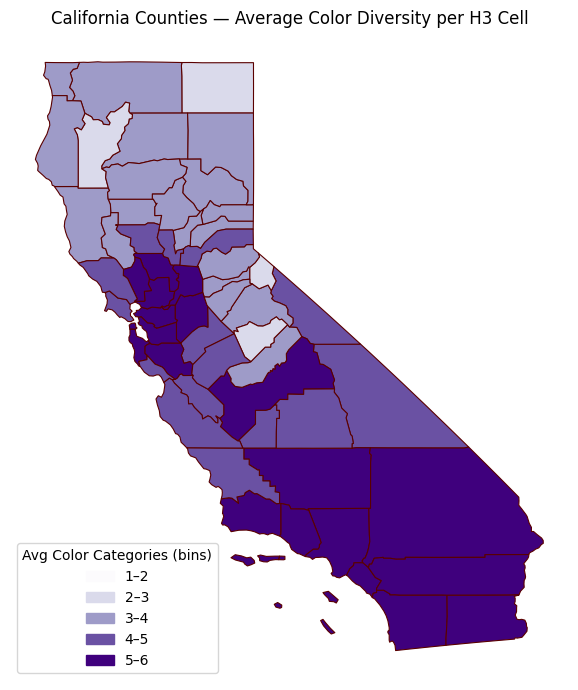

In [14]:
h3_county = df[['h3', 'fips']].drop_duplicates()
h3_diversity_county = h3_diversity.merge(h3_county, on='h3', how='left')
county_diversity = h3_diversity_county.groupby('fips').agg({
    'n_colors': 'mean',
    'n_occupancy': 'mean',
    'n_bldgtype': 'mean'
}).reset_index()
county_diversity.columns = ['county_fips', 'avg_n_colors', 'avg_n_occupancy', 'avg_n_bldgtype']

counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip")
counties_ca = counties[counties["STATEFP"] == "06"].copy()
counties_ca["county_fips"] = counties_ca["GEOID"]

df_county_div = county_diversity.copy()
df_county_div['county_fips'] = df_county_div['county_fips'].astype(int).astype(str).str.zfill(5)

gdf_county_div = counties_ca.merge(df_county_div, on="county_fips", how="left")

breaks_div = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
labels_div = ["1–2", "2–3", "3–4", "4–5", "5–6"]

fig, ax = plt.subplots(figsize=(7, 7))
cmap_div = get_cmap("Purples")
norm_div = BoundaryNorm(breaks_div, ncolors=cmap_div.N, clip=True)

gdf_county_div.plot(
    column="avg_n_colors",
    cmap=cmap_div,
    norm=norm_div,
    linewidth=0.8,
    edgecolor="#5a0000",
    ax=ax,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)

ax.set_axis_off()
ax.set_title("California Counties — Average Color Diversity per H3 Cell", fontsize=12)

patches_div = []
for i, lab in enumerate(labels_div):
    lo, hi = breaks_div[i], breaks_div[i+1]
    sample = (lo + hi) / 2
    patches_div.append(mpatches.Patch(color=cmap_div(norm_div(sample)), label=lab))

ax.legend(
    handles=patches_div,
    title="Avg Color Categories (bins)",
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_diversity_by_county_map.png', dpi=150, bbox_inches='tight')
plt.show()


### Sparsity pattern by county


C:\Users\sardo\AppData\Local\Temp\ipykernel_37448\2504986739.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sparse = get_cmap("Blues")


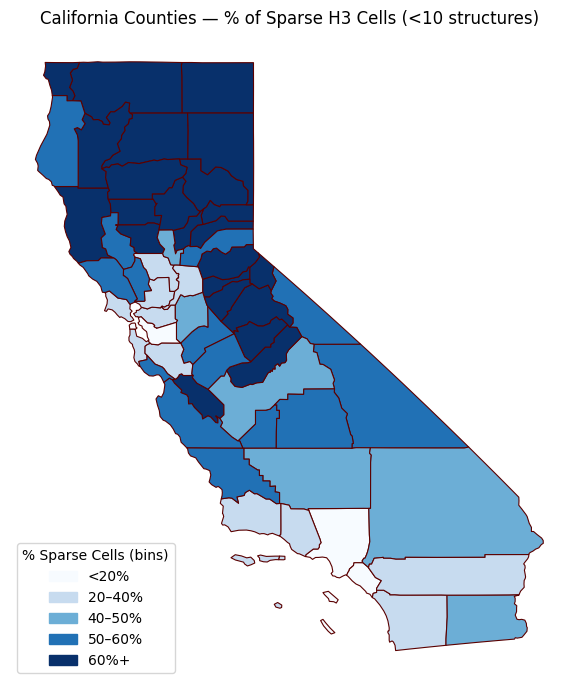

In [15]:
exposure_per_h3_county = exposure_per_h3.merge(h3_county, on='h3', how='left')
sparse_cells = exposure_per_h3_county[exposure_per_h3_county['total_exposure'] < 10]
county_sparsity = sparse_cells.groupby('fips').size().reset_index(name='n_sparse_cells')
county_total_cells = exposure_per_h3_county.groupby('fips').size().reset_index(name='n_total_cells')
county_sparsity = county_sparsity.merge(county_total_cells, on='fips', how='right').fillna(0)
county_sparsity['pct_sparse'] = (county_sparsity['n_sparse_cells'] / county_sparsity['n_total_cells'] * 100).round(1)
county_sparsity.columns = ['county_fips', 'n_sparse_cells', 'n_total_cells', 'pct_sparse']

counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip")
counties_ca = counties[counties["STATEFP"] == "06"].copy()
counties_ca["county_fips"] = counties_ca["GEOID"]

df_county_sparse = county_sparsity.copy()
df_county_sparse['county_fips'] = df_county_sparse['county_fips'].astype(int).astype(str).str.zfill(5)

gdf_county_sparse = counties_ca.merge(df_county_sparse, on="county_fips", how="left")

breaks_sparse = [0, 20, 40, 50, 60, 85]
labels_sparse = ["<20%", "20–40%", "40–50%", "50–60%", "60%+"]

fig, ax = plt.subplots(figsize=(7, 7))
cmap_sparse = get_cmap("Blues")
norm_sparse = BoundaryNorm(breaks_sparse, ncolors=cmap_sparse.N, clip=True)

gdf_county_sparse.plot(
    column="pct_sparse",
    cmap=cmap_sparse,
    norm=norm_sparse,
    linewidth=0.8,
    edgecolor="#5a0000",
    ax=ax,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
)

ax.set_axis_off()
ax.set_title("California Counties — % of Sparse H3 Cells (<10 structures)", fontsize=12)

patches_sparse = []
for i, lab in enumerate(labels_sparse):
    lo, hi = breaks_sparse[i], breaks_sparse[i+1]
    sample = (lo + hi) / 2
    patches_sparse.append(mpatches.Patch(color=cmap_sparse(norm_sparse(sample)), label=lab))

ax.legend(
    handles=patches_sparse,
    title="% Sparse Cells (bins)",
    loc="lower left",
    frameon=True
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_sparsity_by_county_map.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
def categorize_exposure(exposure):
    if exposure < 5:
        return 'Very Low (<5)'
    elif exposure < 10:
        return 'Low (5-9)'
    elif exposure < 20:
        return 'Moderate (10-19)'
    elif exposure < 50:
        return 'Medium (20-49)'
    else:
        return 'High (50+)'

exposure_per_h3['exposure_bin'] = exposure_per_h3['total_exposure'].apply(categorize_exposure)

sparsity_regimes = exposure_per_h3.groupby('exposure_bin').agg({
    'h3': 'count',
    'total_exposure': 'sum'
}).reset_index()
sparsity_regimes.columns = ['exposure_bin', 'n_h3_cells', 'total_structures']

sparsity_regimes['pct_h3_cells'] = (sparsity_regimes['n_h3_cells'] / len(exposure_per_h3) * 100).round(2)
sparsity_regimes['pct_structures'] = (sparsity_regimes['total_structures'] / exposure_per_h3['total_exposure'].sum() * 100).round(2)

bin_order = ['Very Low (<5)', 'Low (5-9)', 'Moderate (10-19)', 'Medium (20-49)', 'High (50+)']
sparsity_regimes['exposure_bin'] = pd.Categorical(sparsity_regimes['exposure_bin'], categories=bin_order, ordered=True)
sparsity_regimes = sparsity_regimes.sort_values('exposure_bin')

print("Sparsity regime analysis:")
display(sparsity_regimes)


Sparsity regime analysis:


,exposure_bin,n_h3_cells,total_structures,pct_h3_cells,pct_structures
4,Very Low (<5),57844,149213,26.16,1.53
1,Low (5-9),26809,179508,12.12,1.85
3,Moderate (10-19),23477,327450,10.62,3.37
2,Medium (20-49),36469,1214795,16.49,12.49
0,High (50+),76509,7857273,34.60,80.77


## Exported tables


In [24]:
exposure_per_h3.to_csv(TABLES_DIR / 'eda_exposure_per_h3.csv', index=False)
landcover_stats.to_csv(TABLES_DIR / 'eda_exposure_by_landcover.csv', index=False)
county_stats.to_csv(TABLES_DIR / 'eda_exposure_by_county.csv', index=False)
sparsity_regimes.to_csv(TABLES_DIR / 'eda_sparsity_regimes.csv', index=False)
h3_diversity.to_csv(TABLES_DIR / 'eda_exposure_diversity.csv', index=False)
